**Task A – ANN for Regression**

# Experiment 1
# ANN for Regression
# Name:AJAIKUMAR M
# Roll No:24BAD005

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf

In [12]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.9144 - mae: 0.6523 - val_loss: 0.4891 - val_mae: 0.4941
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.4133 - mae: 0.4584 - val_loss: 0.4124 - val_mae: 0.4513
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3717 - mae: 0.4353 - val_loss: 0.3986 - val_mae: 0.4369
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.3552 - mae: 0.4241 - val_loss: 0.3796 - val_mae: 0.4301
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.3400 - mae: 0.4140 - val_loss: 0.3685 - val_mae: 0.4287
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3316 - mae: 0.4074 - val_loss: 0.3722 - val_mae: 0.4245
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3312 - mae: 0.4015 - val_loss: 0.3589 - val_mae: 0.4244
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3123 - mae: 0.3921 - val_loss: 0.3564 - val_mae: 0.4314
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

In [16]:
predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Squared Error: 0.2788040677832202
Mean Absolute Error: 0.3603396371108016
Root Mean Squared Error: 0.5280190032406222


**Task B – ANN for Classification**

In [17]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

data = load_breast_cancer()

X = data.data
y = data.target

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
classifier = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

classifier.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

classifier.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
classifier.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.3791 - loss: 0.7858 - val_accuracy: 0.4835 - val_loss: 0.6449
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6978 - loss: 0.5387 - val_accuracy: 0.8571 - val_loss: 0.4824
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9203 - loss: 0.3991 - val_accuracy: 0.9011 - val_loss: 0.3558
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9478 - loss: 0.2792 - val_accuracy: 0.9231 - val_loss: 0.2473
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9505 - loss: 0.1907 - val_accuracy: 0.9231 - val_loss: 0.1836
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9670 - loss: 0.1434 - val_accuracy: 0.9231 - val_loss: 0.1530
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9698 - loss: 0.1180 - val_accuracy: 0.9341 - val_loss: 0.1353
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9780 - loss: 0.1001 - val_accuracy: 0.9341 - val_loss

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


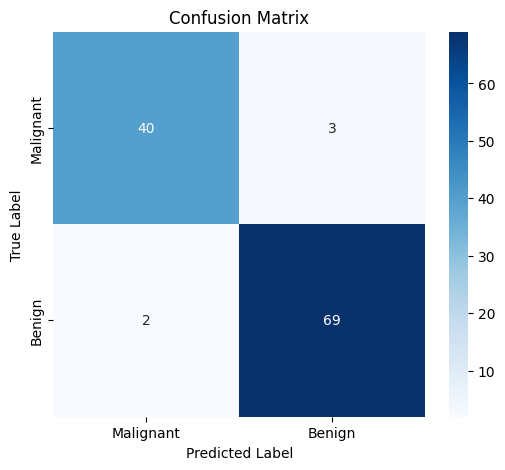

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predict the classes
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot using Seaborn
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()